In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain_openai import AzureChatOpenAI

llm = AzureChatOpenAI(
    azure_deployment='gpt-4o-2024-11-20',
    api_version='2024-08-01-preview'
)

small_llm = AzureChatOpenAI(
    azure_deployment='gpt-4.1-mini',
    api_version='2024-08-01-preview'
)

In [3]:
small_llm.invoke("test")

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 8, 'total_tokens': 18, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}, 'latency_checkpoint': {'engine_tbt_ms': 23, 'engine_ttft_ms': 39, 'engine_ttlt_ms': 273, 'pre_inference_ms': 156, 'service_tbt_ms': 28, 'service_ttft_ms': 564, 'service_ttlt_ms': 792, 'total_duration_ms': 690, 'user_visible_ttft_ms': 408}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_a7294185dc', 'id': 'chatcmpl-DmaRDdErnDa09JNLQv9NRgCK6NQ9m', 'service_tier': 'default', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'detected': False, 'filtered': False}, 'se

In [3]:
from langchain_core.tools import tool

@tool
def add(a: int, b: int) -> int:
    """ 숫자 a와 b를 더합니다. """
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """ 숫자 a와 b를 곱합니다. """
    return a * b

In [5]:
add.invoke({'a': 4, 'b': 8})

12

In [4]:
from langgraph.prebuilt import ToolNode

tool_list = [add, multiply]
llm_with_tools = small_llm.bind_tools(tool_list)
tool_node = ToolNode(tool_list)

In [5]:
multiply.invoke({'a': 3, 'b': 5})

15

In [6]:
ai_message = llm_with_tools.invoke('What is 3 plus 5?')

In [7]:
ai_message

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 84, 'total_tokens': 102, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}, 'latency_checkpoint': {'engine_tbt_ms': 16, 'engine_ttft_ms': 102, 'engine_ttlt_ms': 394, 'pre_inference_ms': 103, 'service_tbt_ms': 14, 'service_ttft_ms': 598, 'service_ttlt_ms': 841, 'total_duration_ms': 746, 'user_visible_ttft_ms': 495}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_a7294185dc', 'id': 'chatcmpl-DnfuZNL2xAaxPWBaKXG6hliZxUnmJ', 'service_tier': 'default', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'detected': False, 'filtered': False}, 'self_harm': {'filtered': False, '

In [ ]:
tool_node.invoke({'messages': [ai_message]}) # 지금은 call 방식이 바뀌었다.

ValueError: Missing required config key 'N/A' for 'tools'.

In [10]:
from langgraph.graph import MessagesState, StateGraph

graph_builder = StateGraph(MessagesState)

In [11]:
def agent(state: MessagesState):
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages': [response]}

In [17]:
from langgraph.graph import END

def should_continue(state: MessagesState):
    messages = state['messages']
    last_ai_message = messages[-1]
    if last_ai_message.tool_calls:
        return 'tools'
    return END

In [13]:
graph_builder.add_node('agent', agent)
graph_builder.add_node('tools', tool_node)

In [ ]:
from langgraph.graph import START

graph_builder.add_edge(START, 'agent')
graph_builder.add_conditional_edges(
    'agent',
    should_continue,
    ['tools', END]
)

graph_builder.add_edge('tools', 'agent')

In [18]:
graph = graph_builder.compile()

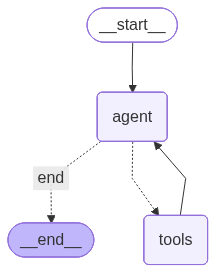

In [19]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [20]:
from langchain_core.messages import HumanMessage

for chunk in graph.stream({'messages': [HumanMessage('3에다가 5를 더하고 거기에 8을 곱하면?')]}, stream_mode='values'):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

3에다가 5를 더하고 거기에 8을 곱하면?
================================== Ai Message ==================================
Tool Calls:
  add (call_u17K9Bci8BhmOJu5NCKg0Uxp)
 Call ID: call_u17K9Bci8BhmOJu5NCKg0Uxp
  Args:
    a: 3
    b: 5
  multiply (call_jSy8dy6o1EAmCnAc3Jok0dIo)
 Call ID: call_jSy8dy6o1EAmCnAc3Jok0dIo
  Args:
    a: 8
    b: 0
================================= Tool Message =================================
Name: multiply

0
================================== Ai Message ==================================
Tool Calls:
  multiply (call_dj6WOPZ3k0N52nW66wobHWA4)
 Call ID: call_dj6WOPZ3k0N52nW66wobHWA4
  Args:
    a: 8
    b: 8
================================= Tool Message =================================
Name: multiply

64
================================== Ai Message ==================================

3에 5를 더하면 8이고, 그 결과에 8을 곱하면 64입니다.
